# My First Data Science Project!
Connor Quadrini


In this project I analyzed statistics from Tom Brady's NFL career. I then made some observations and answered a research question of my choice.


# Dataset

I chose a dataset of Tom Brady's NFL career stats, and I chose it because I think Tom Brady is the best QB of all time, and I'm from the Northeast (not that I'm a Patriots fan). I went about getting this dataset by going to sportsreference.com and editing the dataset to get the stats I wanted.


In [2]:
import pandas as pd
df=pd.read_csv("TomBradyStats.csv")
df

,Rk,Year,Date,G#,Week,Age,Tm,Opp,Result,Cmp,...,TD,Int,Rate,Sk,Yds.1,Y/A,AY/A,R.Att,R.Yds,R.Y/A
0,12,2000,11/23/2000,12,13,23.112,NWE,DET,L 9-34,1,...,0,0,42.4,0,0,2.00,2.00,0,0,NaN
1,18,2001,9/23/2001,2,2,24.051,NWE,NYJ,L 3-10,5,...,0,0,62.9,0,0,4.60,4.60,1,9,9.00
2,19,2001,9/30/2001,3,3,24.058,NWE,IND,W 44-13,13,...,0,0,79.6,1,9,7.30,7.30,1,2,2.00
3,20,2001,10/7/2001,4,4,24.065,NWE,MIA,L 10-30,12,...,0,0,58.7,4,17,3.58,3.58,2,9,4.50
4,21,2001,10/14/2001,5,5,24.072,NWE,SDG,W 29-26,33,...,2,0,93.4,3,19,6.74,7.48,1,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,366,2022,12/11/2022,13,14,45.130,TAM,SFO,L 7-35,34,...,1,2,63.7,0,0,4.60,3.33,2,0,0.00
331,367,2022,12/18/2022,14,15,45.137,TAM,CIN,L 23-34,30,...,3,2,92.2,1,8,7.09,6.41,2,1,0.50
332,368,2022,12/25/2022,15,16,45.144,TAM,ARI,W 19-16,32,...,1,2,71.6,0,0,5.85,4.40,2,1,0.50
333,369,2022,1/1/2023,16,17,45.151,TAM,CAR,W 30-24,34,...,3,0,127.3,3,21,9.60,10.93,3,4,1.33


In [20]:
TotalGames=len(df)
TotalGames

335

In [23]:
TotalCmp=df.Cmp.sum()
TotalCmp

np.int64(7753)

In [ ]:
GamesNWE=len(df[df.Tm=="NWE"])
GamesNWE

285

# Exploratory Data Analysis

Statistics like averages and standard deviations of completion percent (Cmp%) and touchdowns (TD) are a good representation of the data because it shows Tom Brady's performance as his career went on.

In [27]:
df["Cmp%"].mean()


np.float64(64.13925373134329)

In [28]:
df["Cmp%"].std()

np.float64(9.213817908954992)

In [29]:
df.TD.mean()

np.float64(1.9373134328358208)

In [30]:
df.TD.std()

np.float64(1.2735019167652035)

I found that there is a lot more variance in the number of touchdowns made per game than in the competion percent, and this is likely because normally quaterbacks get 0-4 touchdowns per game, whereas completion percent can be anywhere from 0-100.

# Exploratory Data Visualization

<Axes: title={'center': 'Tom Brady Career Touchdowns'}, xlabel='Touchdowns', ylabel='Frequency'>

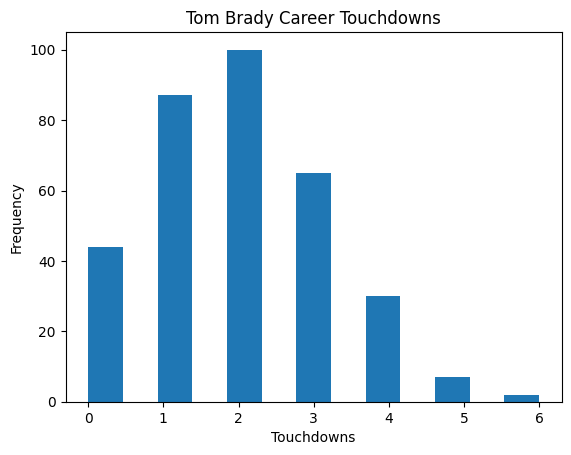

In [10]:
df.TD.plot.hist(title="Tom Brady Career Touchdowns",xlabel="Touchdowns",ylabel="Frequency",bins=13)

<Axes: title={'center': 'Tom Brady Career Completion Percent'}, xlabel='Completion Percent', ylabel='Frequency'>

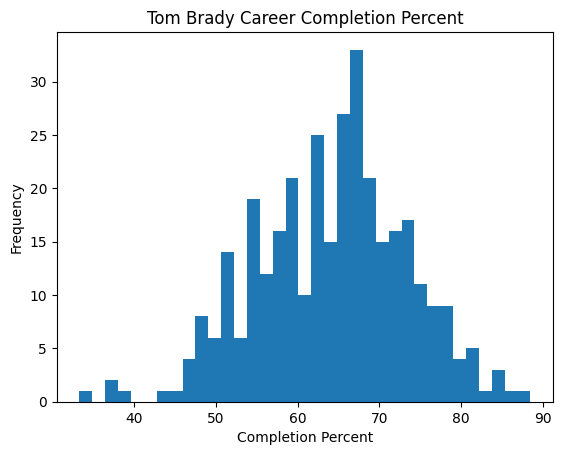

In [61]:
df["Cmp%"].plot.hist(title="Tom Brady Career Completion Percent",xlabel="Completion Percent",ylabel="Frequency",bins=35)

These visualizations show the frequency of the number of Touchdowns Tom Brady got per game and frequency of completion percentage for every game he played throughout his NFL career.

# Planning for Part II

Some observations I've made are that real data like the compeltion percent was hard to make look nice in a graph, and it's important to consdier the range of data when inputting the number of bins, or else your data will look strange on the graph. I also realized that the type of graph is very important because at first when I tried a regular plot, it had 300+ x-axis values and looked unreadable. Making my graphs into density histograms made it much neater and easier to follow.

Some specific questions I'd like to analyze are how did Tom Brady's performance flucuate over his career, and what years he was the best. This will be difficult to do because I will need to use graphs that oversee stats in chronological order (which will be very large), rather than evaluating a simple density histogram.

# What year was Tom Brady the best at football?

One question I want to answer from the previous section is "What year was Tom Brady the best at football?" I could answer this by using groupby to sort the dataframe by years and then observing what years (seasons) he threw the most touchdowns, has the highest average completion percent, and/or has the most average yards per game.

In [6]:
year_df=df.groupby("Year").agg("mean",numeric_only=True).reset_index()
year_df

,Year,Rk,G#,Week,Age,Cmp,Att,Cmp%,Yds,TD,Int,Rate,Sk,Yds.1,Y/A,AY/A,R.Att,R.Yds,R.Y/A
0,2000,12.0,12.0,13.000000,23.112000,1.000000,3.000000,33.330000,6.000000,0.000000,0.000000,42.400000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,NaN
1,2001,25.0,9.0,9.066667,24.100400,17.600000,27.533333,63.742000,189.533333,1.200000,0.800000,85.993333,2.733333,14.400000,6.818000,6.513333,2.400000,2.866667,1.610667
2,2002,40.5,8.5,9.125000,25.092813,23.312500,37.562500,61.497500,235.250000,1.750000,0.875000,85.568750,1.937500,11.875000,6.317500,6.252500,2.625000,6.875000,2.413333
3,2003,56.5,8.5,8.937500,26.090500,19.812500,32.937500,59.206875,226.250000,1.437500,0.750000,85.387500,2.000000,13.687500,6.767500,6.609375,2.625000,3.937500,1.429333
4,2004,72.5,8.5,9.375000,27.098562,18.000000,29.625000,60.190625,230.750000,1.750000,0.875000,93.225000,1.625000,10.125000,7.793125,7.630000,2.687500,1.750000,1.197333
5,2005,88.5,8.5,9.125000,28.095750,20.875000,33.125000,62.240000,256.875000,1.625000,0.875000,92.987500,1.625000,11.750000,7.752500,7.525625,1.687500,5.562500,3.714286
6,2006,104.5,8.5,9.187500,29.095375,19.937500,32.250000,61.299375,220.562500,1.500000,0.750000,88.725000,1.625000,10.937500,6.800625,6.755625,3.062500,6.375000,1.948571
7,2007,120.5,8.5,8.937500,30.092625,24.875000,36.125000,69.366875,300.375000,3.125000,0.500000,114.712500,1.312500,8.000000,8.459375,9.582500,2.312500,6.125000,2.842857
8,2008,129.0,1.0,1.000000,31.035000,7.000000,11.000000,63.640000,76.000000,0.000000,0.000000,83.900000,0.000000,0.000000,6.910000,6.910000,0.000000,0.000000,NaN
9,2009,152.5,8.5,9.062500,32.097563,23.187500,35.312500,65.764375,274.875000,1.750000,0.812500,94.256250,1.000000,5.375000,7.895000,7.850000,1.812500,2.750000,2.130769


# Different Data Visualization



<Axes: title={'center': 'Tom Brady Career Completion Percent'}, xlabel='Years into carrer', ylabel=' Average Completion Percent'>

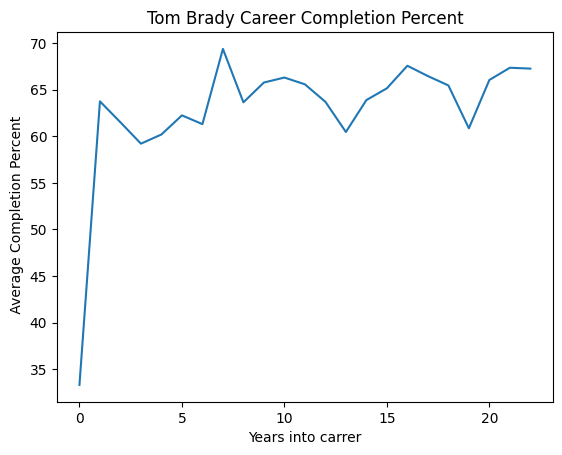

In [21]:
year_df["Cmp%"].plot.line(title="Tom Brady Career Completion Percent",xlabel="Years into carrer",ylabel=" Average Completion Percent")

<Axes: title={'center': 'Tom Brady Career Touchdowns'}, xlabel='Years into carrer', ylabel='Average Touchdown Passes'>

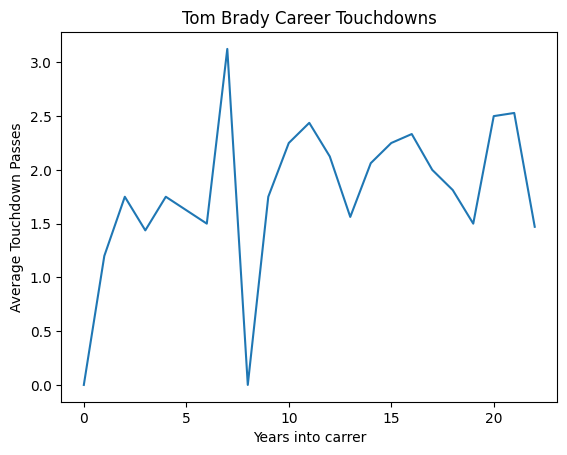

In [18]:
year_df["TD"].plot.line(title="Tom Brady Career Touchdowns",xlabel="Years into carrer",ylabel="Average Touchdown Passes")

<Axes: title={'center': 'Tom Brady Career Passing Yards'}, xlabel='Years into carrer', ylabel='Average Yards Thrown'>

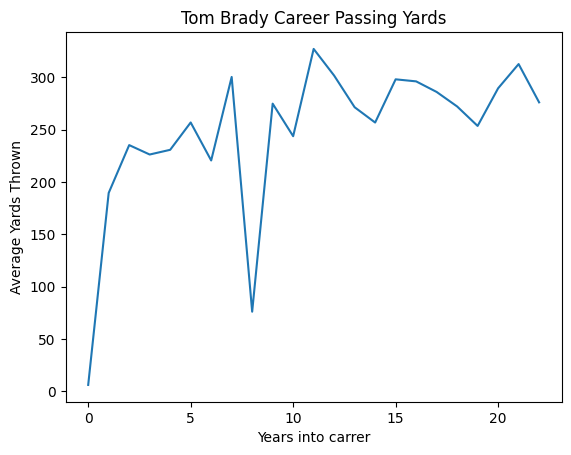

In [23]:
year_df["Yds"].plot.line(title="Tom Brady Career Passing Yards",xlabel="Years into carrer",ylabel="Average Yards Thrown")

These data visualizations show how Tom Brady's average completion percent, number of touchdowns, and passing yards per season fluctuated has he continued his career. Taking all the graphs into account, I believe Tom Brady played the best football, in 2007 because he has the highest Touchdown rate and completion percent in this season than in any other season. Even though his average passing yards weren't as high as some other seasons, it was still very comparable and not far off from his best seasons in terms of yards.

# Overall Summary

In summary, my dataset contains all of Tom Brady's stats through every game in the regular season, and for every year he played in the NFL. I tackled the question of "What year was Tom Brady the best at football?" and I came to the conclusion that he played best in 2007 with New England, which I based off his average touchdowns, passing yards, and completion percent in that season. His average completion percent through this season was just under 70%, he averaged just over 3 touchdowns a game, and slightly over 300 passing yards. Key visualizations were the line graphs in the previous section that grouped Tom Brady's stats by year so I could analyze the data much easier. Thus, in part 1 of the project I observed career wide frequencies of certain stats, but in order to successfully answer my question I had to look at how Tom Brady's stats changed as his football career went on